# KOA — DenseNet-201 (ImageNet-pretrained) — Ritish
**Correct / controlled method** — identical to the other three members'
notebooks in every respect except the model, so the four-way comparison is fair.

Design: 80% train / 20% test, **no validation**, ImageNet normalization,
robust 16-bit TIFF loader, train-only augmentation, Grade-4 oversampling,
fixed 30 epochs, final model tested on the frozen test set. Writes results to
`MyDrive/KOA/runs/densenet/` (read by the combiner notebook).

### Before you run
- Put your per-batch zips in Drive (`batch_500.zip` … `batch_4686.zip`). The
  notebook finds them even with odd names, and auto-skips any that are missing.
- **Runtime → Change runtime type → GPU**, then Run all.


In [ ]:
import torch, torchvision, sys
print("python:", sys.version.split()[0], "| torch:", torch.__version__)
print("GPU   :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (set Runtime -> GPU!)")


python: 3.13.15 | torch: 2.11.0+cu128
GPU   : Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ============================================================
# CONFIG   (only MEMBER / MODEL_NAME / LR differ between members)
# ============================================================
MEMBER      = "Ritish"
MODEL_NAME  = "densenet"          # folder name the combiner expects

DRIVE_ROOT  = "/content/drive/MyDrive"
DRIVE_OUT   = "/content/drive/MyDrive/KOA/runs"   # results -> runs/densenet/
LOCAL_ROOT  = "/content/koa"

BATCHES     = [500, 1000, 1500, 2000, 3000, 4686]
EPOCHS      = 30
BATCH_SIZE  = 32
LR          = 1e-4
NUM_WORKERS = 2
SAVE_CHECKPOINTS = True       # set False if your Drive is nearly full

# ---- SHARED POLICY (identical for all four members) ----
IMAGE_SIZE, NUM_CLASSES, SEED = 224, 5, 42
MEAN = [0.485, 0.456, 0.406]     # ImageNet
STD  = [0.229, 0.224, 0.225]


In [ ]:
# ============================================================
# SHARED POLICY: seed, robust loader, transforms, sampler, metrics
# (IDENTICAL for all four members)
# ============================================================
import os, json, glob, zipfile, shutil, random
import numpy as np
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             cohen_kappa_score, confusion_matrix)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Robust loader: correct for 8-bit AND 16-bit TIFF (per-image min-max -> 8-bit RGB).
def load_xray(path):
    arr = np.asarray(Image.open(path)).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]
    mn, mx = float(arr.min()), float(arr.max())
    arr = (arr - mn) / (mx - mn + 1e-6)
    return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(degrees=7, translate=(0.03,0.03), scale=(0.95,1.05)),
        transforms.ColorJitter(brightness=0.10, contrast=0.10),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def eval_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

def make_weighted_sampler(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    w = (1.0/np.maximum(counts,1))[labels]
    return WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)

def compute_metrics(yt, yp):
    wp,wr,wf,_ = precision_recall_fscore_support(yt,yp,average="weighted",zero_division=0)
    mp,mr,mf,_ = precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)
    return {"accuracy":float(accuracy_score(yt,yp)),
            "weighted_precision":float(wp),"weighted_recall":float(wr),"weighted_f1":float(wf),
            "macro_precision":float(mp),"macro_recall":float(mr),"macro_f1":float(mf),
            "cohen_kappa":float(cohen_kappa_score(yt,yp)),
            "quadratic_weighted_kappa":float(cohen_kappa_score(yt,yp,weights="quadratic"))}


In [ ]:
# ============================================================
# MODEL: DenseNet-201 (ImageNet-pretrained, plain 5-class head)
# ============================================================
def build_model(n=NUM_CLASSES):
    m = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
    m.classifier = nn.Linear(m.classifier.in_features, n)
    return m


In [ ]:
# ============================================================
# LOCATE + EXTRACT each per-batch zip (handles messy names)
# ============================================================
ALL_ZIPS = glob.glob(os.path.join(DRIVE_ROOT, "**", "*.zip"), recursive=True)

def find_zip(batch):
    key = f"batch_{batch}"
    cands = [p for p in ALL_ZIPS if key in os.path.basename(p)]
    return sorted(cands, key=len)[0] if cands else None

def find_batch_root(root):
    for dp, dns, _ in os.walk(root):
        if "train" in dns and "test" in dns:
            return dp
    return None

def prepare_batch(batch):
    dest = os.path.join(LOCAL_ROOT, f"b{batch}")
    root = find_batch_root(dest)
    if root: return root
    zp = find_zip(batch)
    if zp is None: return None
    os.makedirs(dest, exist_ok=True)
    print(f"  extracting {os.path.basename(zp)} ...")
    with zipfile.ZipFile(zp) as z: z.extractall(dest)
    return find_batch_root(dest)

print("zips found:", [os.path.basename(p) for p in ALL_ZIPS])


zips found: ['batch_500.zip', 'batch_1000.zip', 'batch_1500.zip', 'batch_2000 1.zip', 'batch_3000.zip', 'batch_4686.zip']


In [ ]:
# ============================================================
# TRAIN (fixed epochs, no validation) + FROZEN-TEST EVAL
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_one_epoch(model, loader, crit, opt):
    model.train(); tot=0.0; correct=0; n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out, y)
        loss.backward(); opt.step()
        tot += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tot/n, correct/n

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x,y in loader:
        out = model(x.to(device))
        ps.extend(out.argmax(1).cpu().numpy()); ys.extend(y.numpy())
    return np.array(ys), np.array(ps)

def run_batch(batch):
    set_seed(SEED)
    root = prepare_batch(batch)
    if root is None:
        print(f"  batch_{batch}: zip NOT found -> skipped"); return None

    tr = ImageFolder(os.path.join(root,"train"), loader=load_xray, transform=train_transform())
    te = ImageFolder(os.path.join(root,"test"),  loader=load_xray, transform=eval_transform())
    lk = dict(num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
    tl = DataLoader(tr, batch_size=BATCH_SIZE,
                    sampler=make_weighted_sampler([l for _,l in tr.samples]), **lk)
    el = DataLoader(te, batch_size=BATCH_SIZE, shuffle=False, **lk)

    model = build_model().to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    for ep in range(1, EPOCHS+1):
        loss, acc = train_one_epoch(model, tl, crit, opt); sched.step()
        print(f"  batch_{batch} ep{ep:02d} | train_loss {loss:.3f} | train_acc {acc:.3f}")

    yt, yp = evaluate(model, el)                 # FROZEN TEST
    res = compute_metrics(yt, yp); res.update({"model":MODEL_NAME, "batch":batch})

    outdir = os.path.join(DRIVE_OUT, MODEL_NAME); os.makedirs(outdir, exist_ok=True)
    json.dump(res, open(os.path.join(outdir, f"batch_{batch}_metrics.json"),"w"), indent=2)
    np.savetxt(os.path.join(outdir, f"batch_{batch}_confusion.csv"),
               confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES))), fmt="%d", delimiter=",")
    if SAVE_CHECKPOINTS:
        torch.save(model.state_dict(), os.path.join(outdir, f"batch_{batch}_final.pth"))

    shutil.rmtree(os.path.join(LOCAL_ROOT, f"b{batch}"), ignore_errors=True)  # free disk
    print(f"  -> TEST acc {res['accuracy']:.3f} | macroF1 {res['macro_f1']:.3f} "
          f"| QWK {res['quadratic_weighted_kappa']:.3f}")
    return res


In [ ]:
# ============================================================
# RUN ALL AVAILABLE BATCHES
# ============================================================
all_results = []
for b in BATCHES:
    print(f"\n===== {MODEL_NAME}  batch_{b} =====")
    r = run_batch(b)
    if r is not None: all_results.append(r)
print("\nDone.")



===== densenet  batch_500 =====
  extracting batch_500.zip ...
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:02<00:00, 32.7MB/s]
/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")
/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")


  batch_500 ep01 | train_loss 1.392 | train_acc 0.429


/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")
/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")


  batch_500 ep02 | train_loss 0.968 | train_acc 0.649


...

  batch_4686 ep29 | train_loss 0.007 | train_acc 0.998


/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")
/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")


  batch_4686 ep30 | train_loss 0.007 | train_acc 0.998


/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")
/tmp/ipykernel_1664/2601672850.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((arr * 255).astype(np.uint8), mode="L").convert("RGB")


  -> TEST acc 0.699 | macroF1 0.472 | QWK 0.738

Done.


 training_images  accuracy  macro_f1  weighted_f1  quadratic_weighted_kappa
             500  0.638978  0.366335     0.589275                  0.665151
            1000  0.629393  0.388789     0.586555                  0.640089
            1500  0.653887  0.394250     0.608338                  0.677987
            2000  0.685836  0.480415     0.652082                  0.731354
            3000  0.697551  0.447513     0.660914                  0.728165
            4686  0.698616  0.472188     0.667380                  0.737966


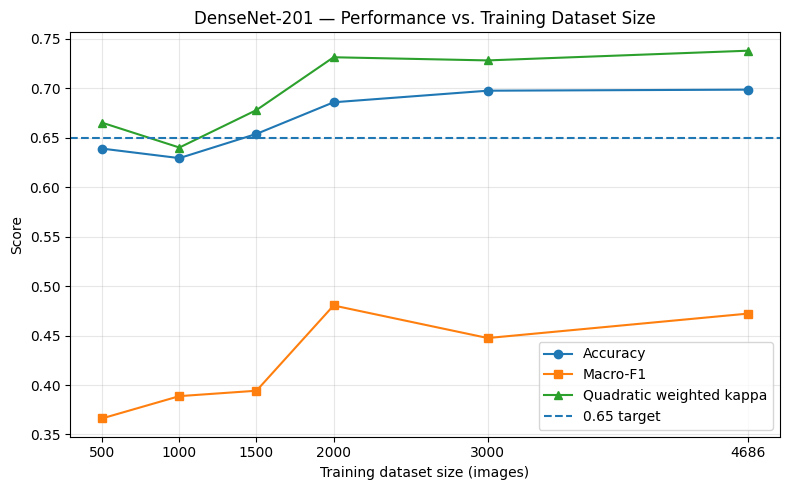

In [ ]:
# ============================================================
# PERFORMANCE VS TRAINING DATASET SIZE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Existing results from your completed experiments
data = [
    [500,  0.638978, 0.366335, 0.589275, 0.665151],
    [1000, 0.629393, 0.388789, 0.586555, 0.640089],
    [1500, 0.653887, 0.394250, 0.608338, 0.677987],
    [2000, 0.685836, 0.480415, 0.652082, 0.731354],
    [3000, 0.697551, 0.447513, 0.660914, 0.728165],
    [4686, 0.698616, 0.472188, 0.667380, 0.737966],
]

df = pd.DataFrame(
    data,
    columns=[
        "training_images",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "quadratic_weighted_kappa"
    ]
)

print(df.to_string(index=False))

# ============================================================
# GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["training_images"],
    df["accuracy"],
    "o-",
    label="Accuracy"
)

plt.plot(
    df["training_images"],
    df["macro_f1"],
    "s-",
    label="Macro-F1"
)

plt.plot(
    df["training_images"],
    df["quadratic_weighted_kappa"],
    "^-",
    label="Quadratic weighted kappa"
)

# Target
plt.axhline(
    0.65,
    linestyle="--",
    label="0.65 target"
)

plt.xlabel("Training dataset size (images)")
plt.ylabel("Score")

plt.title(
    "DenseNet-201 — Performance vs. Training Dataset Size"
)

plt.xticks(df["training_images"])

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
print("Performance for each training dataset size")
print("=" * 70)

for _, row in df.iterrows():
    print(f"\nTraining images: {int(row['training_images'])}")
    print(f"Accuracy:                  {row['accuracy']:.4f} ({row['accuracy']*100:.2f}%)")
    print(f"Macro-F1:                  {row['macro_f1']:.4f}")
    print(f"Weighted-F1:               {row['weighted_f1']:.4f}")
    print(f"Quadratic Weighted Kappa:  {row['quadratic_weighted_kappa']:.4f}")

Performance for each training dataset size

Training images: 500
Accuracy:                  0.6390 (63.90%)
Macro-F1:                  0.3663
Weighted-F1:               0.5893
Quadratic Weighted Kappa:  0.6652

Training images: 1000
Accuracy:                  0.6294 (62.94%)
Macro-F1:                  0.3888
Weighted-F1:               0.5866
Quadratic Weighted Kappa:  0.6401

Training images: 1500
Accuracy:                  0.6539 (65.39%)
Macro-F1:                  0.3942
Weighted-F1:               0.6083
Quadratic Weighted Kappa:  0.6780

Training images: 2000
Accuracy:                  0.6858 (68.58%)
Macro-F1:                  0.4804
Weighted-F1:               0.6521
Quadratic Weighted Kappa:  0.7314

Training images: 3000
Accuracy:                  0.6976 (69.76%)
Macro-F1:                  0.4475
Weighted-F1:               0.6609
Quadratic Weighted Kappa:  0.7282

Training images: 4686
Accuracy:                  0.6986 (69.86%)
Macro-F1:                  0.4722
Weighted-F1:      

### Notes
- **Controlled version** — same loader, transforms, normalization, sampler,
  epochs, batch size, schedule and frozen test set as the other three members.
  Only `build_model` differs. That is what keeps the comparison valid.
- **No validation by design.** Fixed 30 epochs, final model tested. Don't tune
  `EPOCHS` by watching the test score — that leaks the test set.
- **Report all three** — accuracy, macro-F1, quadratic-weighted kappa. On a
  54%-majority test set, accuracy alone flatters a model that ignores Grade 4.
